# NYC Taxi Economics: Fare, Tipping & Demand (2025)

Analysis of NYC TLC yellow and green taxi trips for calendar year 2025 (~35.3M cleaned trips), read from the `marts` schema of the project's Postgres warehouse (`fact_trips`, `agg_daily_zone`, `agg_hourly_demand`, `dq_summary`, `dq_rejection_reasons`, `dim_zone`).

Findings are summarized in plain language in [`report/findings.md`](../report/findings.md); this notebook is the analysis behind that report.

In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlalchemy as sa
from dotenv import load_dotenv

load_dotenv("../.env")

url = (
    f"postgresql+psycopg2://{os.environ['WAREHOUSE_DB_USER']}:{os.environ['WAREHOUSE_DB_PASSWORD']}"
    f"@{os.environ['WAREHOUSE_DB_HOST']}:{os.environ['WAREHOUSE_DB_PORT']}/{os.environ['WAREHOUSE_DB_NAME']}"
)
engine = sa.create_engine(url)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

# Validated categorical palette (fixed order - never reassigned by category identity)
BLUE, ORANGE, AQUA, GOLD, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"
)
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 110,
})

YELLOW_C, GREEN_C = BLUE, ORANGE  # fixed categorical order: taxi_type is series 1/2, not literal cab color


## 1. Data cleaning summary

Before looking at any trend, it's worth knowing how much of the raw data was usable and why the rest wasn't &mdash; the cleaning rules (invalid fare, distance, passenger count, duration, unknown zone, or a corrupted pickup timestamp) are applied in `fact_trips` (see `dbt/taxi_analytics/models/marts/`), and every excluded row is preserved in `rejected_trips` / `dq_rejection_reasons` rather than silently dropped.

In [2]:
dq = pd.read_sql("""
    select taxi_type,
           sum(total_trips) as total_trips,
           sum(clean_trips) as clean_trips,
           sum(rejected_trips) as rejected_trips
    from dbt_dev_marts.dq_summary
    where month between '2025-01-01' and '2025-12-01'
    group by 1
""", engine)
dq["rejection_rate_pct"] = (dq.rejected_trips / dq.total_trips * 100).round(1)
dq


,taxi_type,total_trips,clean_trips,rejected_trips,rejection_rate_pct
0,green,591354.0,501561.0,89793.0,15.2
1,yellow,48722573.0,34764140.0,13958433.0,28.6


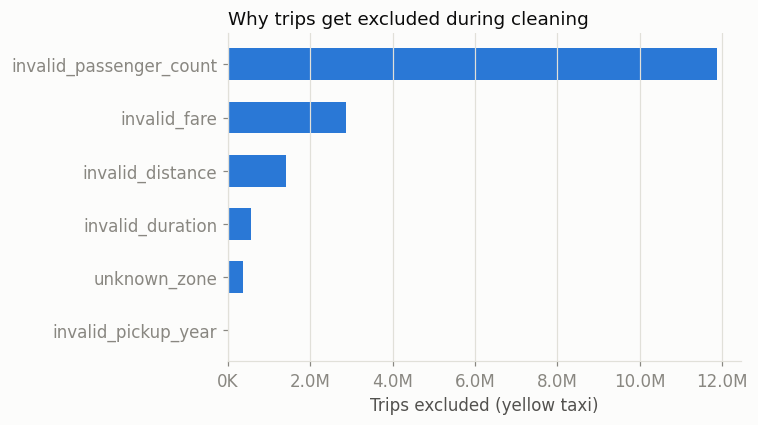

Yellow: 28.6% of raw trips excluded (13,958,433 of 48,722,573)
Green:  15.2% of raw trips excluded (89,793 of 591,354)


In [3]:
reasons = pd.read_sql(
    "select * from dbt_dev_marts.dq_rejection_reasons order by taxi_type, trip_count desc", engine
)
yellow_reasons = reasons[reasons.taxi_type == "yellow"].sort_values("trip_count")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(yellow_reasons.rejection_reason, yellow_reasons.trip_count, color=BLUE, height=0.6)
ax.set_xlabel("Trips excluded (yellow taxi)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.set_title("Why trips get excluded during cleaning", loc="left", fontsize=12, color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"Yellow: {dq.loc[dq.taxi_type=='yellow','rejection_rate_pct'].iloc[0]}% of raw trips excluded "
      f"({dq.loc[dq.taxi_type=='yellow','rejected_trips'].iloc[0]:,.0f} of "
      f"{dq.loc[dq.taxi_type=='yellow','total_trips'].iloc[0]:,.0f})")
print(f"Green:  {dq.loc[dq.taxi_type=='green','rejection_rate_pct'].iloc[0]}% of raw trips excluded "
      f"({dq.loc[dq.taxi_type=='green','rejected_trips'].iloc[0]:,.0f} of "
      f"{dq.loc[dq.taxi_type=='green','total_trips'].iloc[0]:,.0f})")


## 2. Market structure: yellow vs. green

Green ("boro taxi") trips were introduced in 2013 to serve areas yellow cabs rarely covered. By 2025 green is a rounding error next to yellow — worth quantifying rather than assuming.

In [4]:
monthly = pd.read_sql("""
    select date_trunc('month', pickup_date)::date as month,
           taxi_type,
           sum(trip_count) as trips,
           sum(total_revenue) as revenue,
           sum(total_revenue) / nullif(sum(trip_count),0) as avg_fare,
           sum(avg_trip_distance * trip_count) / nullif(sum(trip_count),0) as avg_distance,
           sum(cbd_trip_count) as cbd_trips
    from dbt_dev_marts.agg_daily_zone
    where pickup_date >= '2025-01-01' and pickup_date <= '2025-12-31'
    group by 1,2
    order by 1,2
""", engine)

yellow_m = monthly[monthly.taxi_type == "yellow"].set_index("month")
green_m = monthly[monthly.taxi_type == "green"].set_index("month")

total_yellow, total_green = yellow_m.trips.sum(), green_m.trips.sum()
share_green = total_green / (total_yellow + total_green) * 100
print(f"2025 totals: {total_yellow:,.0f} yellow trips vs {total_green:,.0f} green trips")
print(f"Green's share of combined volume: {share_green:.2f}%")


2025 totals: 34,764,139 yellow trips vs 501,561 green trips
Green's share of combined volume: 1.42%


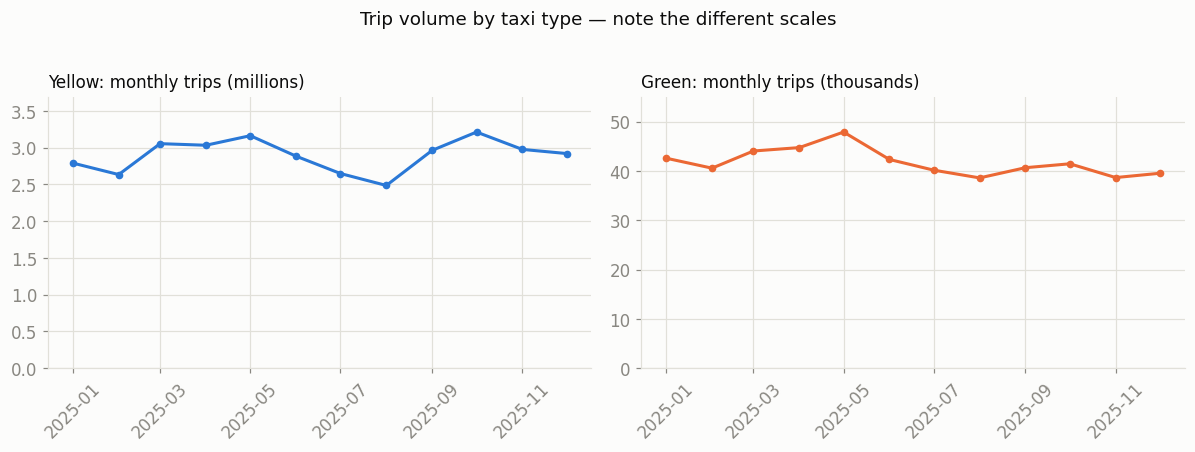

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

axes[0].plot(yellow_m.index, yellow_m.trips / 1e6, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[0].set_title("Yellow: monthly trips (millions)", loc="left", fontsize=11, color=INK)
axes[0].set_ylim(0, yellow_m.trips.max() / 1e6 * 1.15)

axes[1].plot(green_m.index, green_m.trips / 1e3, color=ORANGE, linewidth=2, marker="o", markersize=4)
axes[1].set_title("Green: monthly trips (thousands)", loc="left", fontsize=11, color=INK)
axes[1].set_ylim(0, green_m.trips.max() / 1e3 * 1.15)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Trip volume by taxi type — note the different scales", fontsize=12, color=INK, y=1.02)
plt.tight_layout()
plt.show()


## 3. Demand patterns: when and where trips happen

Grain here is yellow taxi only (98.6% of volume) so the pattern isn't diluted by green's much smaller, noisier counts.

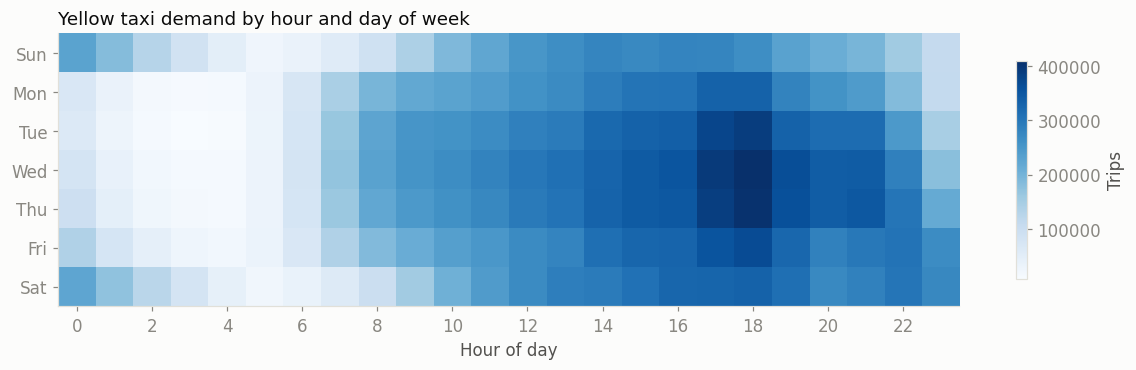

Peak demand hour: 18:00 (2,499,624 trips/yr at that hour)
Lowest demand hour: 4:00 (161,939 trips/yr at that hour)


In [6]:
hourly = pd.read_sql("""
    select extract(dow from pickup_date)::int as day_of_week,
           pickup_hour,
           sum(trip_count) as trips
    from dbt_dev_marts.agg_hourly_demand
    where taxi_type = 'yellow'
      and pickup_date >= '2025-01-01' and pickup_date <= '2025-12-31'
    group by 1,2
""", engine)

pivot = hourly.pivot(index="day_of_week", columns="pickup_hour", values="trips")
pivot.index = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_yticks(range(7)); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_title("Yellow taxi demand by hour and day of week", loc="left", fontsize=12, color=INK)
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, label="Trips")
plt.tight_layout()
plt.show()

by_hour_total = hourly.groupby("pickup_hour").trips.sum()
peak_hour = by_hour_total.idxmax()
trough_hour = by_hour_total.idxmin()
print(f"Peak demand hour: {peak_hour}:00 ({by_hour_total.max():,.0f} trips/yr at that hour)")
print(f"Lowest demand hour: {trough_hour}:00 ({by_hour_total.min():,.0f} trips/yr at that hour)")


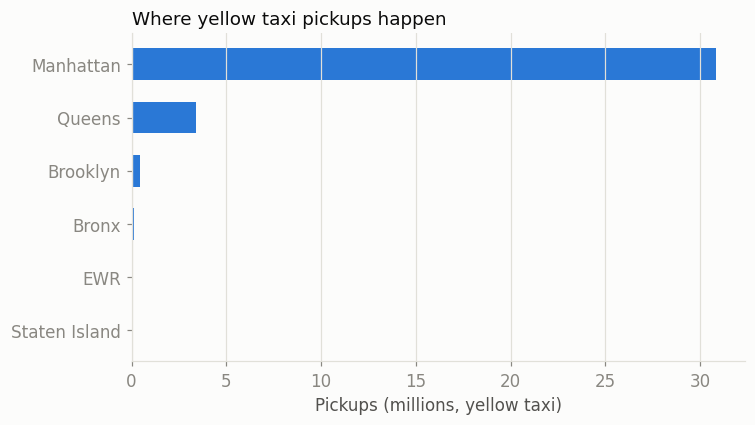

,borough,trips,avg_fare
8,EWR,1178.0,101.349839
10,Queens,3389404.0,73.039372
6,Bronx,131311.0,39.194273
11,Staten Island,796.0,34.486759
7,Brooklyn,436713.0,33.106052
9,Manhattan,30804737.0,24.148823


In [7]:
borough = pd.read_sql("""
    select taxi_type, borough,
           sum(trip_count) as trips,
           sum(total_revenue) as revenue,
           sum(total_revenue)/nullif(sum(trip_count),0) as avg_fare
    from dbt_dev_marts.agg_daily_zone
    where pickup_date >= '2025-01-01' and pickup_date <= '2025-12-31'
    group by 1,2
""", engine)
yb = borough[borough.taxi_type == "yellow"].sort_values("trips")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(yb.borough, yb.trips / 1e6, color=BLUE, height=0.6)
ax.set_xlabel("Pickups (millions, yellow taxi)")
ax.set_title("Where yellow taxi pickups happen", loc="left", fontsize=12, color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

yb_sorted = yb.sort_values("avg_fare", ascending=False)[["borough","trips","avg_fare"]]
yb_sorted


## 4. Fare trends

Average fare and average trip distance both moved over the year; congestion-pricing exposure (the `cbd_congestion_fee`, in effect since January 2025) is tracked separately since it's a flat per-trip charge, not a fare-distance effect.

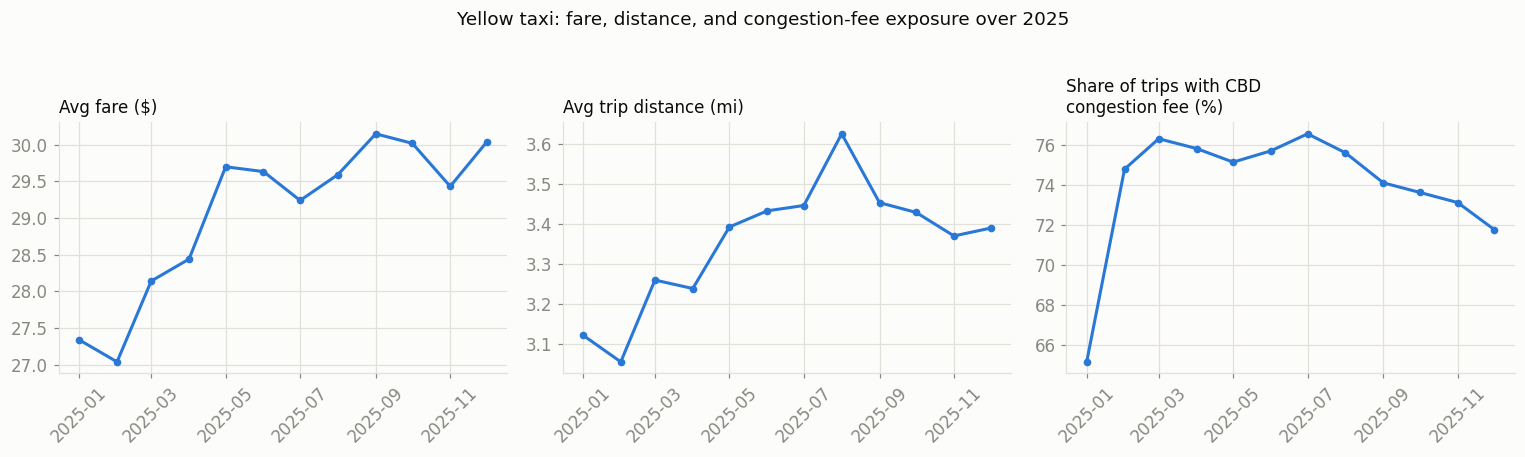

Avg fare: $27.34 (Jan) -> $30.04 (Dec), +9.9%
CBD-fee trip share: 65.1% (Jan) -> 71.8% (Dec), +6.6pp


In [8]:
yellow_m = yellow_m.copy()
yellow_m["cbd_share_pct"] = yellow_m.cbd_trips / yellow_m.trips * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(yellow_m.index, yellow_m.avg_fare, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[0].set_title("Avg fare ($)", loc="left", fontsize=11, color=INK)

axes[1].plot(yellow_m.index, yellow_m.avg_distance, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[1].set_title("Avg trip distance (mi)", loc="left", fontsize=11, color=INK)

axes[2].plot(yellow_m.index, yellow_m.cbd_share_pct, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[2].set_title("Share of trips with CBD\ncongestion fee (%)", loc="left", fontsize=11, color=INK)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Yellow taxi: fare, distance, and congestion-fee exposure over 2025", fontsize=12, color=INK, y=1.03)
plt.tight_layout()
plt.show()

fare_change = (yellow_m.avg_fare.iloc[-1] / yellow_m.avg_fare.iloc[0] - 1) * 100
cbd_change = yellow_m.cbd_share_pct.iloc[-1] - yellow_m.cbd_share_pct.iloc[0]
print(f"Avg fare: ${yellow_m.avg_fare.iloc[0]:.2f} (Jan) -> ${yellow_m.avg_fare.iloc[-1]:.2f} (Dec), {fare_change:+.1f}%")
print(f"CBD-fee trip share: {yellow_m.cbd_share_pct.iloc[0]:.1f}% (Jan) -> {yellow_m.cbd_share_pct.iloc[-1]:.1f}% (Dec), {cbd_change:+.1f}pp")


## 5. Tipping behavior

**Caveat that matters for everything below:** TLC only records `tip_amount` for card payments — cash tips are invisible in this data. So tipping metrics here are restricted to card trips, and the payment-type mix itself is worth checking first.

In [9]:
pay = pd.read_sql("""
    select taxi_type, payment_type, count(*) as trips
    from dbt_dev_marts.fact_trips
    where pickup_date >= '2025-01-01' and pickup_date <= '2025-12-31'
    group by 1,2
""", engine)
PAYMENT_LABELS = {1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown"}
pay["payment_label"] = pay.payment_type.map(PAYMENT_LABELS)
pay["share_pct"] = pay.groupby("taxi_type").trips.transform(lambda s: s / s.sum() * 100)
pay.pivot(index="payment_label", columns="taxi_type", values="share_pct").round(1)


taxi_type,green,yellow
payment_label,,
Cash,24.3,12.1
Credit card,75.4,86.0
Dispute,0.1,1.5
No charge,0.3,0.4
Unknown,0.0,0.0


In [10]:
# One full scan of fact_trips, card payments only, at (taxi_type, hour, day-of-week, borough, month) grain -
# fine enough to slice every tipping cut below from a single query rather than one scan per chart.
tip_cube = pd.read_sql("""
    select
        f.taxi_type,
        extract(dow from f.pickup_date)::int as day_of_week,
        f.pickup_hour,
        z.borough,
        date_trunc('month', f.pickup_date)::date as month,
        count(*) as trips,
        avg(f.tip_pct) as avg_tip_pct
    from dbt_dev_marts.fact_trips f
    left join dbt_dev_marts.dim_zone z on f.pu_location_id = z.location_id
    where f.payment_type = 1
      and f.pickup_date >= '2025-01-01' and f.pickup_date <= '2025-12-31'
    group by 1,2,3,4,5
""", engine)

def wavg(df, col, weight="trips"):
    return (df[col] * df[weight]).sum() / df[weight].sum()

for t in ["yellow", "green"]:
    sub = tip_cube[tip_cube.taxi_type == t]
    print(f"{t}: {wavg(sub, 'avg_tip_pct'):.2f}% average tip (card payments, n={sub.trips.sum():,.0f})")


yellow: 25.30% average tip (card payments, n=29,881,930)
green: 22.57% average tip (card payments, n=377,961)


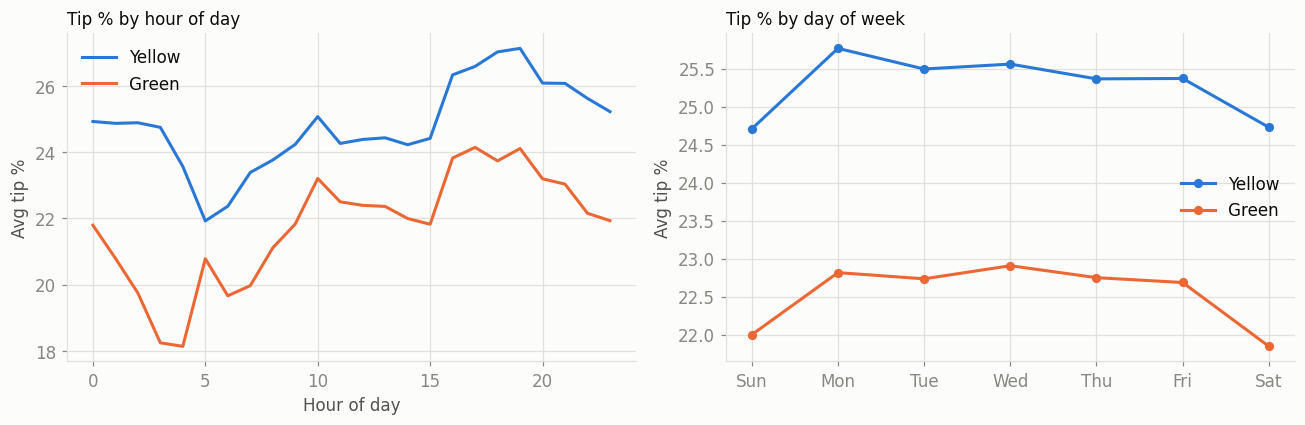

Yellow tip% range across hours: 21.9% (low, 5:00) to 27.1% (high, 19:00)


In [11]:
by_hour = (tip_cube.groupby(["taxi_type", "pickup_hour"])
           .apply(lambda d: wavg(d, "avg_tip_pct")).rename("avg_tip_pct").reset_index())
hp = by_hour.pivot(index="pickup_hour", columns="taxi_type", values="avg_tip_pct")

by_dow = (tip_cube.groupby(["taxi_type", "day_of_week"])
          .apply(lambda d: wavg(d, "avg_tip_pct")).rename("avg_tip_pct").reset_index())
dp = by_dow.pivot(index="day_of_week", columns="taxi_type", values="avg_tip_pct")
dp.index = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hp.index, hp["yellow"], color=YELLOW_C, linewidth=2, label="Yellow")
axes[0].plot(hp.index, hp["green"], color=GREEN_C, linewidth=2, label="Green")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Avg tip %")
axes[0].set_title("Tip % by hour of day", loc="left", fontsize=11, color=INK)
axes[0].legend(frameon=False)

axes[1].plot(dp.index, dp["yellow"], color=YELLOW_C, linewidth=2, marker="o", markersize=5, label="Yellow")
axes[1].plot(dp.index, dp["green"], color=GREEN_C, linewidth=2, marker="o", markersize=5, label="Green")
axes[1].set_ylabel("Avg tip %")
axes[1].set_title("Tip % by day of week", loc="left", fontsize=11, color=INK)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Yellow tip% range across hours: {hp['yellow'].min():.1f}% (low, {hp['yellow'].idxmin()}:00) "
      f"to {hp['yellow'].max():.1f}% (high, {hp['yellow'].idxmax()}:00)")


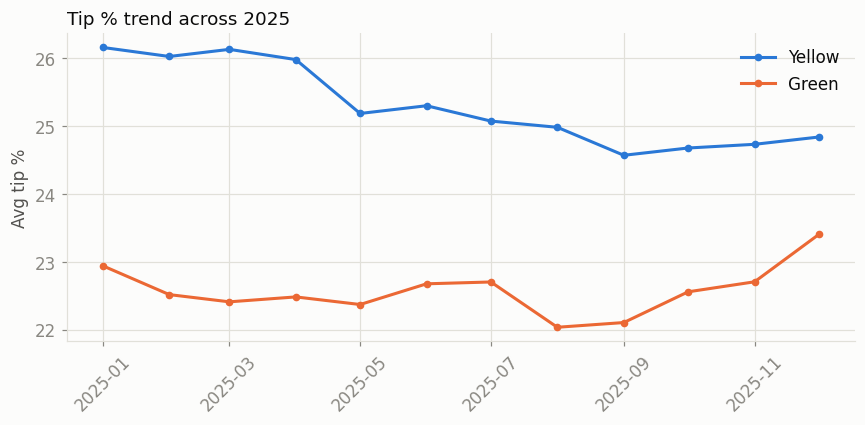

Yellow tip%: 26.2% (Jan) -> 24.8% (Dec)
Green tip%:  22.9% (Jan) -> 23.4% (Dec)


In [12]:
by_month = (tip_cube.groupby(["taxi_type", "month"])
            .apply(lambda d: wavg(d, "avg_tip_pct")).rename("avg_tip_pct").reset_index())
mp = by_month.pivot(index="month", columns="taxi_type", values="avg_tip_pct")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mp.index, mp["yellow"], color=YELLOW_C, linewidth=2, marker="o", markersize=4, label="Yellow")
ax.plot(mp.index, mp["green"], color=GREEN_C, linewidth=2, marker="o", markersize=4, label="Green")
ax.set_ylabel("Avg tip %")
ax.set_title("Tip % trend across 2025", loc="left", fontsize=12, color=INK)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Yellow tip%: {mp['yellow'].iloc[0]:.1f}% (Jan) -> {mp['yellow'].iloc[-1]:.1f}% (Dec)")
print(f"Green tip%:  {mp['green'].iloc[0]:.1f}% (Jan) -> {mp['green'].iloc[-1]:.1f}% (Dec)")


## 6. Tipping by pickup borough

This cut turned up the sharpest pattern in the whole analysis, so it gets a dedicated section rather than one more line in the chart above.

In [13]:
by_borough = (tip_cube[tip_cube.taxi_type == "yellow"].groupby("borough")
              .apply(lambda d: pd.Series({"avg_tip_pct": wavg(d, "avg_tip_pct"), "trips": d.trips.sum()}))
              .reset_index().sort_values("trips", ascending=False))
by_borough


,borough,avg_tip_pct,trips
3,Manhattan,26.130975,26632435.0
4,Queens,21.082743,2720745.0
1,Brooklyn,6.193854,403134.0
0,Bronx,0.932198,124330.0
2,EWR,18.776847,1091.0
5,Staten Island,18.261385,195.0


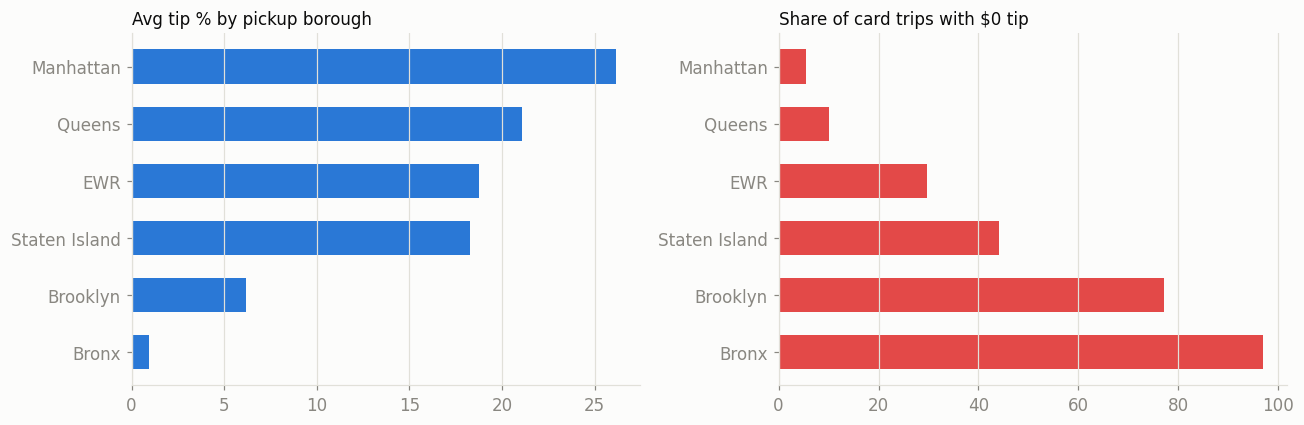

,borough,total_trips,avg_tip_pct,zero_tip_pct
3,Manhattan,26632435,26.130975,5.461307
4,Queens,2720745,21.082743,10.124984
2,EWR,1091,18.776847,29.789184
5,Staten Island,195,18.261385,44.102564
1,Brooklyn,403134,6.193854,77.160200
0,Bronx,124330,0.932198,96.959704


In [14]:
# how much of the low average is trips recording literally $0 tip, vs a broad low-but-nonzero pattern?
zero_tip = pd.read_sql("""
    select z.borough,
           count(*) filter (where f.tip_amount = 0) as zero_tip_trips,
           count(*) as total_trips
    from dbt_dev_marts.fact_trips f
    join dbt_dev_marts.dim_zone z on f.pu_location_id = z.location_id
    where f.taxi_type = 'yellow' and f.payment_type = 1
      and f.pickup_date >= '2025-01-01' and f.pickup_date <= '2025-12-31'
    group by 1
""", engine)
zero_tip["zero_tip_pct"] = zero_tip.zero_tip_trips / zero_tip.total_trips * 100
zero_tip = zero_tip.merge(by_borough[["borough", "avg_tip_pct"]], on="borough").sort_values("total_trips", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = zero_tip.sort_values("avg_tip_pct").borough
axes[0].barh(order, zero_tip.set_index("borough").loc[order, "avg_tip_pct"], color=BLUE, height=0.6)
axes[0].set_title("Avg tip % by pickup borough", loc="left", fontsize=11, color=INK)
axes[0].grid(axis="y", visible=False)

axes[1].barh(order, zero_tip.set_index("borough").loc[order, "zero_tip_pct"], color=RED, height=0.6)
axes[1].set_title("Share of card trips with $0 tip", loc="left", fontsize=11, color=INK)
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

zero_tip[["borough", "total_trips", "avg_tip_pct", "zero_tip_pct"]].sort_values("zero_tip_pct")


## 7. Summary of key findings

- **Green taxi is a rounding error.** ~1.4% of combined 2025 yellow+green volume, despite green existing specifically to serve outer boroughs — which yellow now also serves in meaningful volume.
- **Demand is Manhattan- and evening-centered.** The large majority of yellow pickups originate in Manhattan; the hour-of-day/day-of-week heatmap shows a clear evening peak and an overnight trough.
- **Queens' high average fare is an airport artifact, not a pricing story** — driven by JFK/LGA flat-rate and long-distance trips, not a systematically pricier borough.
- **Fares rose over the year** alongside a rising share of trips carrying the CBD congestion fee.
- **Tipping is time-sensitive:** evening trips tip meaningfully better than early-morning trips, and yellow taxi's average tip rate drifted down over the course of the year.
- **Tipping by borough is the standout finding:** Manhattan pickups average ~26% tips with only ~6% of card trips at $0; Brooklyn and the Bronx average a fraction of that, driven by 77% and 97% $0-tip rates respectively. That's too large and too systematic to be sampling noise, but this data can't say *why* on its own — flagged here as a lead for further investigation, not a settled explanation.
- **Cleaning removed a substantial share of yellow trips (28.6%)**, almost entirely on `invalid_passenger_count` — worth knowing before treating headline averages as being over "all" trips.

Full narrative write-up: [`report/findings.md`](../report/findings.md).